# **Topic: Analyzing University Rankings: Trends and Insights from North American Institutions**

# **1. Problem Definition and understanding**

> **1.1 Problem Definition**

The dataset contains information about universities in North America, including their rankings, country, year of establishment, number of students, academic staff, tuition fees, library volumes, and endowments.

The goal is to analyze and extract meaningful insights from this data, such as identifying trends, comparing institutions, and understanding factors that contribute to higher rankings.

 Dataset Link :https://www.kaggle.com/datasets/puzanov/top-200-universities-in-north-america








> **1.2 Asking questions**

1.  How does the number of students affect university ranking?

2.  How does financial endowment impact university size and ranking?

3.  What is the relationship between the number of academic staff and university size?

4.  Do larger universities have better academic rankings?

5.  How does the number of library volumes relate to university size?

6. To what extent do the number of students, academic staff, tuition cost, and endowment influence university ranking?

7. Does university endowment (financial funding) impact the number of students and academic staff?

8. Do universities with larger libraries (more volumes) achieve better rankings?

9. How does the number of students and academic staff vary by university ranking across different countries?

10. How does the ratio of students to academic staff impact university ranking, and how does this ratio vary across countries?

11. How does the year a university was established impact its ranking, and is there a trend between older universities and their rankings?


# **2.Data understanding**

> **2.1 Dataset Overview**



The dataset contains information about **200 universities** in **North America**, covering attributes related to ranking, size, financial endowment, and academic resources. Below is a summary of the dataset columns:

| **Column Name**            | **Description**                                             | **Data Type** |
|----------------------------|-------------------------------------------------------------|--------------|
| **Rank**                   | University ranking                                          | Integer     |
| **Name**                   | Name of the university                                     | String      |
| **Country**                | Country of the university (e.g., US, Canada)              | String      |
| **Established**            | Year the university was founded                           | Integer     |
| **Academic Staff**         | Number of academic staff members                          | Float       |
| **Number of Students**     | Total number of students enrolled                         | Float       |
| **Minimum Tuition cost**   | Minimum tuition fees (contains currency symbols)         | String      |
| **Volumes in the library** | Number of volumes available in the university library    | Float       |
| **Endowment**              | University’s financial endowment (contains currency symbols) | String      |




In [23]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [27]:
df = pd.read_csv("/content/NorthAmericaUniversities.csv", encoding='latin-1')
df.head()

,Rank,Name,Country,Established,Academic Staff,Number of Students,Minimum Tuition cost,Volumes in the library,Endowment
0,1,Massachusetts Institute of Technology,us,1861,1069.0,11920.0,"$50,000.00",1351391.0,$24.6B
1,2,Harvard University,us,1636,2400.0,21613.0,"$50,000.00",14440248.0,$50.7B
2,3,Stanford University,us,1885,2323.0,17529.0,"$50,000.00",6625926.0,$36.5B
3,4,Cornell University,us,1865,1639.0,26284.0,"$50,000.00",5270855.0,$10.7B
4,5,"University of California, Berkeley",us,1868,NaN,45307.0,"$12,500.00",7718398.0,$7.4B


In [28]:
df.tail()


,Rank,Name,Country,Established,Academic Staff,Number of Students,Minimum Tuition cost,Volumes in the library,Endowment
195,196,"University of Maryland, Baltimore",us,1807,2321.0,6239.0,"$10,000.00",246706.0,$1.5B
196,197,Western Michigan University,us,1903,751.0,17605.0,"$12,500.00",1513540.0,$0.6402B
197,198,Baylor College of Medicine,us,1900,5486.0,1577.0,NaN,122927.0,$1.6B
198,199,The New School,us,1919,2230.0,10186.0,"$50,000.00",288816.0,$0.3935B
199,200,Nova Southeastern University,us,1964,1676.0,20576.0,"$30,000.00",520098.0,$0.185B


In [29]:
df.columns

Index(['Rank', 'Name', 'Country', 'Established', 'Academic Staff',
       'Number of Students', 'Minimum Tuition cost', 'Volumes in the library',
       'Endowment'],
      dtype='object')

In [30]:
df.shape

(200, 9)

In [31]:
df.size

1800

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Rank                    200 non-null    int64  
 1   Name                    200 non-null    object 
 2   Country                 200 non-null    object 
 3   Established             200 non-null    int64  
 4   Academic Staff          181 non-null    float64
 5   Number of Students      199 non-null    float64
 6   Minimum Tuition cost    196 non-null    object 
 7   Volumes in the library  176 non-null    float64
 8   Endowment               198 non-null    object 
dtypes: float64(3), int64(2), object(4)
memory usage: 14.2+ KB


In [33]:
df.describe()

,Rank,Established,Academic Staff,Number of Students,Volumes in the library
count,200.000000,200.000000,181.000000,199.000000,1.760000e+02
mean,100.500000,1875.990000,2632.530387,29964.045226,2.178546e+06
std,57.879185,56.941298,1940.948590,17395.568965,2.295093e+06
min,1.000000,1636.000000,161.000000,1577.000000,1.202800e+04
25%,50.750000,1849.500000,1288.000000,17078.000000,9.074560e+05
50%,100.500000,1876.000000,2103.000000,26809.000000,1.501361e+06
75%,150.250000,1908.000000,3476.000000,39093.500000,2.597085e+06
max,200.000000,1974.000000,10810.000000,101816.000000,1.444025e+07



***Based on our data exploration and statistical summary, we can conclude the following:***  

- The dataset contains **200 universities**, but some features have missing values, particularly in **Academic Staff, Number of Students, and Volumes in the Library**.  
- **Academic Staff** numbers vary widely, ranging from **161 to 10,810**, with an average of **2,632**, indicating significant variation among universities.  
- **Number of Students** spans from **1,577 to 101,816**, with a median of **26,809**, showing a mix of small and large universities.  
- **Year of Establishment** ranges from **1636 to 1974**, highlighting a long history of universities in North America.  
- The data distribution suggests the presence of **outliers**, particularly in student count and academic staff numbers, which might require further analysis or handling.  

These insights provide a solid foundation for further investigation, such as identifying factors that contribute to higher rankings or analyzing trends in tuition costs and financial endowments.

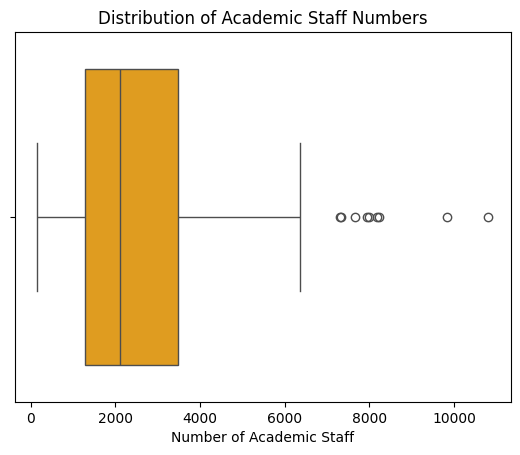

In [34]:
sns.boxplot(x=df["Academic Staff"], color="orange")
plt.title("Distribution of Academic Staff Numbers")
plt.xlabel("Number of Academic Staff")
plt.show()

The box plot shows **high variation** in academic staff numbers.

Most universities have between 1,288 and 3,476 staff, with a median of 2,103. However, a few universities exceed 10,000, **making them outliers, indicating a right-skewed distribution.**

 This suggests that while **most universities have moderate faculty sizes, a few elite institutions employ significantly larger numbers.**

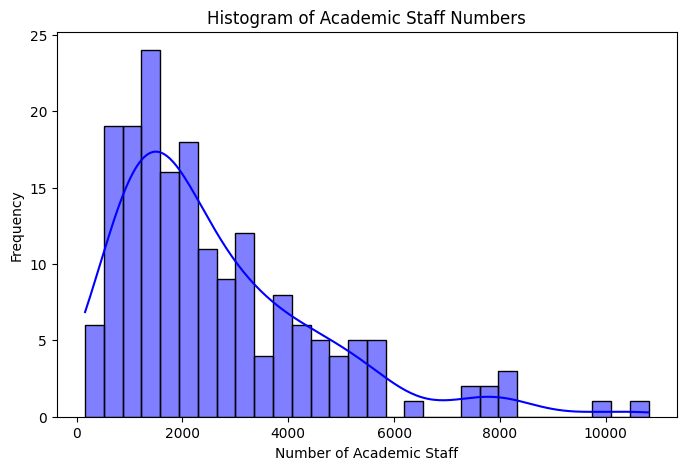

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Academic Staff"].dropna(), bins=30, kde=True, color="blue")
plt.title("Histogram of Academic Staff Numbers")
plt.xlabel("Number of Academic Staff")
plt.ylabel("Frequency")
plt.show()


The histogram shows the **distribution of academic staff numbers** across universities.

The **Y-axis (frequency**) represents the **number of universities** in each staff range.

Most universities have **1,000 to 4,000 academic staff**, with a peak around **1,500 to 2,500.**

A few universities have **over 8,000 staff**, making them **outliers**.

The distribution is **right-skewed**, indicating that while most universities have moderate faculty sizes, a few have significantly larger numbers.

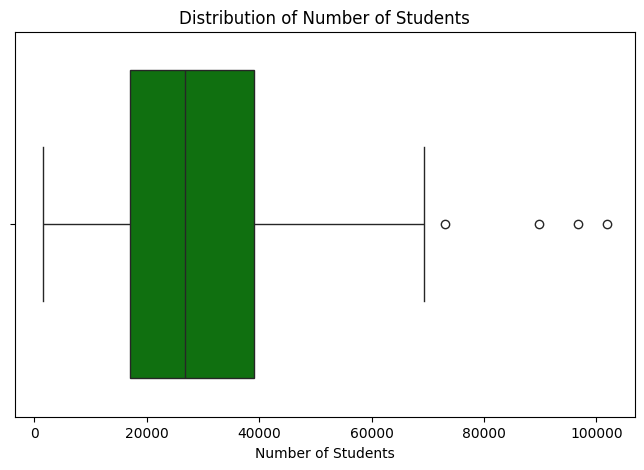

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Number of Students"], color="green")
plt.title("Distribution of Number of Students")
plt.xlabel("Number of Students")
plt.show()

The box plot shows **high variation in the number of students** across universities.

Most universities have **between 15,000 and 45,000 students, with a median of around 26,809.**

A few universities **exceed 80,000 students**, making them **outliers.**

The distribution **is right-skewed**, indicating that while most universities have moderate student populations, some large institutions significantly raise the upper limit.

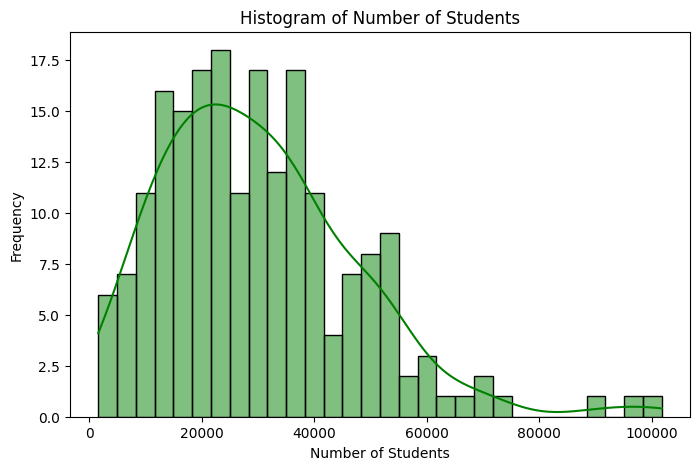

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Number of Students"].dropna(), bins=30, kde=True, color="green")
plt.title("Histogram of Number of Students")
plt.xlabel("Number of Students")
plt.ylabel("Frequency")
plt.show()

The histogram represents the distribution of **student populations across universities.**

The Y-axis (Frequency) indicates the **number of universities** within each student range.

Most universities have between **10,000 and 40,000 students, with the highest frequency around 20,000 to 30,000 students.**

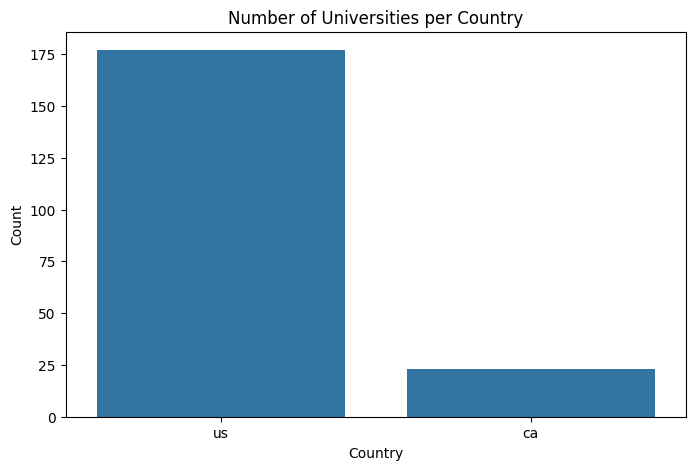

In [38]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df["Country"])
plt.title("Number of Universities per Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

**The bar chart** shows a significant disparity in the number of universities between the United States (US) and Canada (CA).

The **majority of universities in the dataset are from the US**, with a much **smaller proportion from Canada.**

This suggests that the **higher education sector in the US** is significantly larger c**ompared to Canada** in terms of the number of institutions.

<ipython-input-93-c0789752d4eb>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Established Decade', data=df, palette='coolwarm')


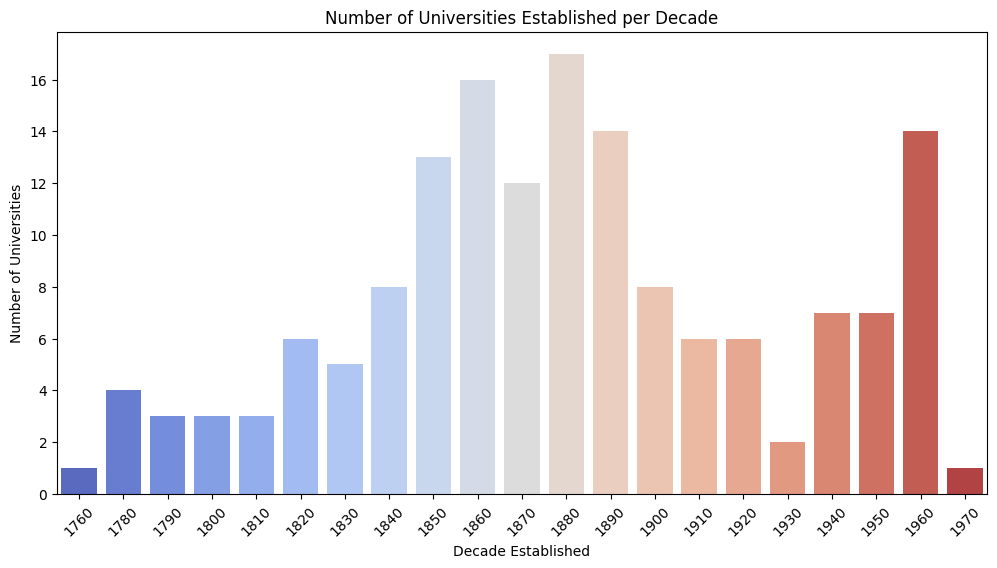

In [93]:
# Create a new column to group the "Established" years by decades
df['Established Decade'] = (df['Established'] // 10) * 10

# Plotting the number of universities established per decade
plt.figure(figsize=(12, 6))
sns.countplot(x='Established Decade', data=df, palette='coolwarm')
plt.title('Number of Universities Established per Decade')
plt.xlabel('Decade Established')
plt.ylabel('Number of Universities')
plt.xticks(rotation=45)
plt.show()


### **Summary of the Results: Number of Universities Established per Decade**

- The **bar chart** shows the **number of universities established per decade**.
- A significant **increase in the number of universities** can be seen starting from the **1860s**, peaking around the **1960s**, with a notable **surge** during this period.
- The **1800s** saw a slower pace of university establishment, while the **20th century** experienced a rapid growth, especially in the **1960s**.
- After the 1960s, the **number of universities** established starts to decrease, though still higher than earlier decades.

This analysis shows a clear trend of expanding higher education, particularly in the mid-20th century.

# **3.Data Cleaning and Preprocessing**

**This stage focuses on cleaning and preparing the dataset for analysis by:**

1. Converting text-based numerical data (e.g., tuition fees, endowments) into proper numeric formats.
2. Handling missing values (filling or removing them).
3.  Removing duplicate records to ensure data integrity.
4. Outlier Handling
5.  Ensuring data consistency before moving to the analysis phase

> **Step 1: Convert Text-Based Numeric Data to Proper Numeric Values**

In [39]:
# Convert 'Minimum Tuition cost' column to string type before applying .str accessor
df["Minimum Tuition cost"] = df["Minimum Tuition cost"].astype(str).str.replace("[$,]", "", regex=True).astype(float)
df["Endowment"] = df["Endowment"].astype(str).str.replace("[$,B]", "", regex=True).astype(float) * 1e9

df.dtypes

,0
Rank,int64
Name,object
Country,object
Established,int64
Academic Staff,float64
Number of Students,float64
Minimum Tuition cost,float64
Volumes in the library,float64
Endowment,float64


We converted financial values to numbers because they had symbols like $ and B. Now, we can calculate, compare, and analyze tuition fees and endowments properly.



**Step 2: Check for Missing Values**



In [40]:
print("Missing Values Report:\n", df.isnull().sum())

Missing Values Report:
 Rank                       0
Name                       0
Country                    0
Established                0
Academic Staff            19
Number of Students         1
Minimum Tuition cost       4
Volumes in the library    24
Endowment                  2
dtype: int64


We used the median because it is less affected by extreme values. This makes it a more reliable choice for filling missing data, ensuring the result is not too high or too low.



> **Step 3: Handling Missing Values**


In [41]:
df["Academic Staff"].fillna(df["Academic Staff"].median(), inplace=True)
df["Number of Students"].fillna(df["Number of Students"].median(), inplace=True)
df["Minimum Tuition cost"].fillna(df["Minimum Tuition cost"].median(), inplace=True)
df["Volumes in the library"].fillna(df["Volumes in the library"].median(), inplace=True)
df["Endowment"].fillna(df["Endowment"].median(), inplace=True)
print("Missing Values After Cleaning:\n", df.isnull().sum())

Missing Values After Cleaning:
 Rank                      0
Name                      0
Country                   0
Established               0
Academic Staff            0
Number of Students        0
Minimum Tuition cost      0
Volumes in the library    0
Endowment                 0
dtype: int64


<ipython-input-41-e5686298d2df>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Academic Staff"].fillna(df["Academic Staff"].median(), inplace=True)
<ipython-input-41-e5686298d2df>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [42]:
print("Missing Values After Cleaning:\n", df.isnull().sum())

Missing Values After Cleaning:
 Rank                      0
Name                      0
Country                   0
Established               0
Academic Staff            0
Number of Students        0
Minimum Tuition cost      0
Volumes in the library    0
Endowment                 0
dtype: int64




>  **Step 4: Check for Duplicates and Remove Them if Necessary**



In [43]:
# Check the number of duplicate rows
print("Number of duplicate rows before cleaning:", df.duplicated().sum())

Number of duplicate rows before cleaning: 0


In [44]:
# Remove duplicate rows
df = df.drop_duplicates()

In [45]:
# Verify after removing duplicates
print("Number of duplicate rows after cleaning:", df.duplicated().sum())

Number of duplicate rows after cleaning: 0


>  **Step 5: Outlier Handling**

In [46]:
numeric_columns = ["Academic Staff", "Number of Students", "Minimum Tuition cost", "Endowment"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers_iqr = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]

    print(f"   - Outliers detected by IQR: {outliers_iqr.shape[0]}")


   - Outliers detected by IQR: 10
   - Outliers detected by IQR: 4
   - Outliers detected by IQR: 0
   - Outliers detected by IQR: 29


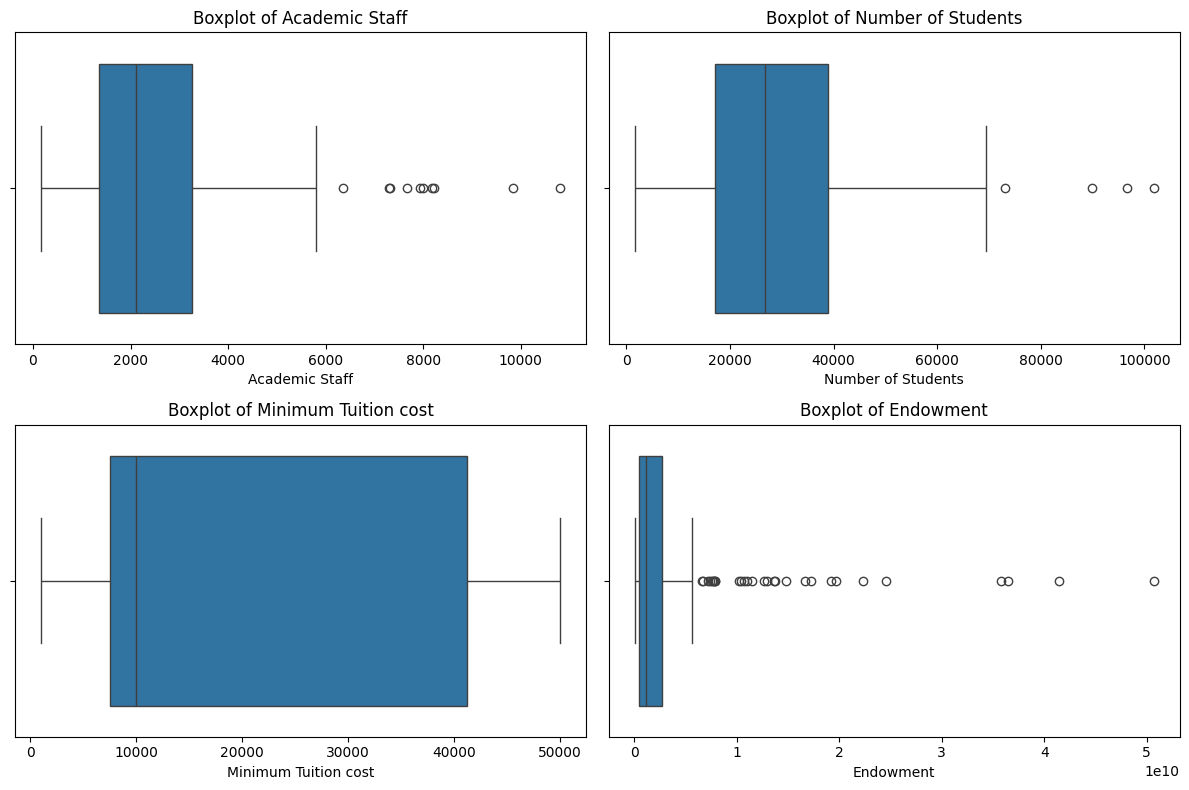

In [47]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(["Academic Staff", "Number of Students", "Minimum Tuition cost", "Endowment"], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [48]:
print("Original shape:", df.shape)

Original shape: (200, 9)


In [49]:
def remove_outliers_iqr(df):
    """
    Removes outliers from a DataFrame using the Interquartile Range (IQR) method.

    :param df: The original DataFrame.
    :return: A new DataFrame without outliers.
    """

    # Select only numeric columns to avoid issues with categorical data
    df_numeric = df.select_dtypes(include=[np.number])


    # Compute Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df_numeric.quantile(0.25)
    Q3 = df_numeric.quantile(0.75)


    # Compute the Interquartile Range (IQR)
    IQR = Q3 - Q1


    # Define lower and upper bounds for outlier detection
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    # Create a mask to filter out rows containing any outliers
    mask = ~((df_numeric < lower_bound) | (df_numeric > upper_bound)).any(axis=1)


    # Apply the mask to remove outliers
    cleaned_df = df[mask].copy()


    return cleaned_df


In [50]:
# Apply the function to remove outliers and update df
df = remove_outliers_iqr(df)

In [51]:
print("New shape after removing outliers:", df.shape)

New shape after removing outliers: (156, 9)


In [52]:
df.size

1404

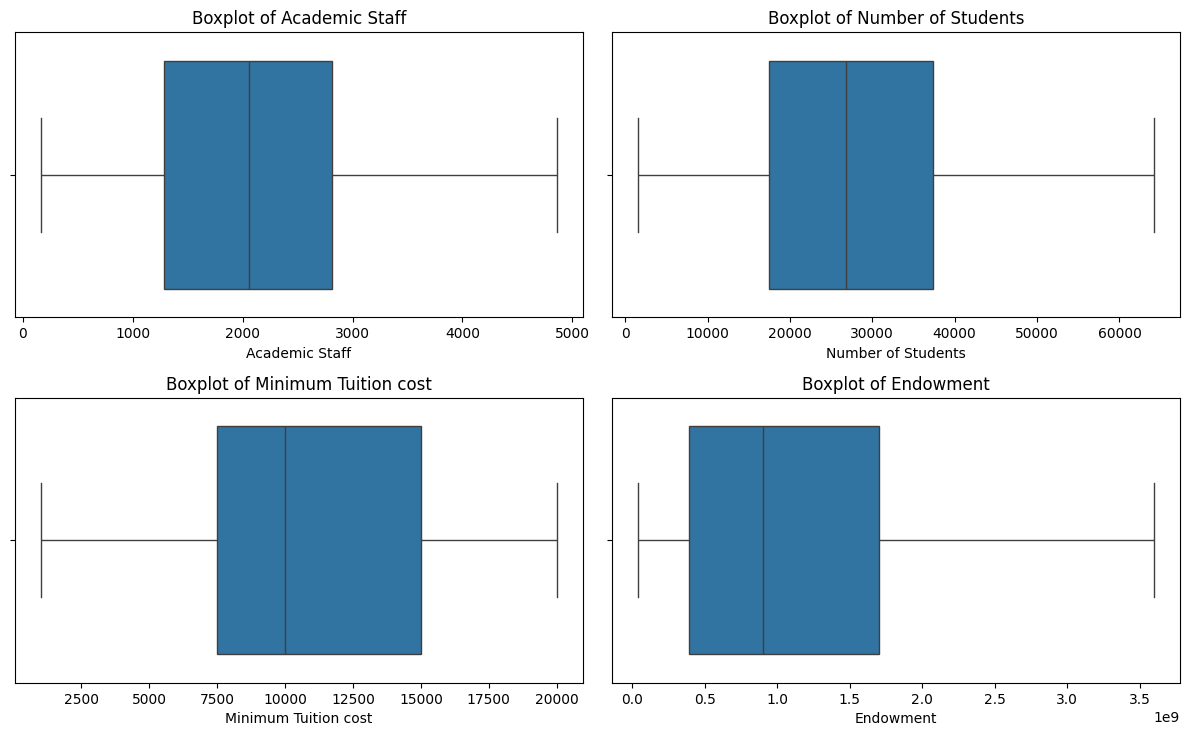

In [53]:
plt.figure(figsize=(12, 18))
# Increased number of rows to 3 to accommodate more subplots
num_cols = len(df.columns)
num_rows = (num_cols + 1) // 2  # Calculate rows needed
for i, col in enumerate(["Academic Staff", "Number of Students", "Minimum Tuition cost", "Endowment"], 1):
    plt.subplot(num_rows, 2, i)  # Use calculated rows
    sns.boxplot(x=df[col], showfliers=False)
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()



Outliers were detected **using the IQR method** (values outside 1.5 × IQR).

A function was created to automatically **remove outliers from the dataset**.

The dataset size changed from **(200,9) to (156,9)**, confirming outliers were removed.

 Boxplots confirmed **bold text** that extreme values were successfully eliminated.

> **Step 6: Save the Cleaned Dataset**

In [54]:
# Save the cleaned dataset
cleaned_file_path = "Cleaned_NorthAmericaUniversities.csv"
df.to_csv(cleaned_file_path, index=False)
print(f"Cleaned dataset saved as {cleaned_file_path}")

Cleaned dataset saved as Cleaned_NorthAmericaUniversities.csv


In [55]:
files.download("Cleaned_NorthAmericaUniversities.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 15 to 199
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Rank                    156 non-null    int64  
 1   Name                    156 non-null    object 
 2   Country                 156 non-null    object 
 3   Established             156 non-null    int64  
 4   Academic Staff          156 non-null    float64
 5   Number of Students      156 non-null    float64
 6   Minimum Tuition cost    156 non-null    float64
 7   Volumes in the library  156 non-null    float64
 8   Endowment               156 non-null    float64
dtypes: float64(5), int64(2), object(2)
memory usage: 12.2+ KB


In [57]:
df.describe()

,Rank,Established,Academic Staff,Number of Students,Minimum Tuition cost,Volumes in the library,Endowment
count,156.000000,156.000000,156.000000,156.000000,156.000000,1.560000e+02,1.560000e+02
mean,115.057692,1884.544872,2181.519231,28007.641026,16983.974359,1.421255e+06,1.218281e+09
std,51.876931,48.349846,1287.418670,14158.460834,16354.778316,8.719909e+05,1.106328e+09
min,16.000000,1766.000000,161.000000,1577.000000,1000.000000,1.202800e+04,4.000000e+07
25%,69.750000,1852.000000,1282.000000,17493.500000,7500.000000,8.863942e+05,3.927500e+08
50%,118.500000,1885.000000,2058.000000,26807.000000,10000.000000,1.423149e+06,9.038000e+08
75%,158.250000,1911.500000,2815.750000,37311.250000,15000.000000,1.704986e+06,1.702500e+09
max,200.000000,1974.000000,5703.000000,69320.000000,50000.000000,4.229493e+06,5.680000e+09


In [58]:
print(df["Endowment"].describe())
print(df[["Endowment"]].head(10))

count    1.560000e+02
mean     1.218281e+09
std      1.106328e+09
min      4.000000e+07
25%      3.927500e+08
50%      9.038000e+08
75%      1.702500e+09
max      5.680000e+09
Name: Endowment, dtype: float64
       Endowment
15  5.366000e+09
16  4.100000e+09
17  2.000000e+09
18  2.500000e+09
24  4.400000e+09
26  5.100000e+09
27  3.000000e+09
28  1.940000e+09
29  1.590000e+09
31  2.100000e+09


# **Now, the dataset is clean and ready for Exploratory Data Analysis (EDA)!**

In [59]:
df = pd.read_csv("/content/Cleaned_NorthAmericaUniversities.csv", encoding='latin-1')
df.head()

,Rank,Name,Country,Established,Academic Staff,Number of Students,Minimum Tuition cost,Volumes in the library,Endowment
0,16,Â University of Minnesota Twin Cities,us,1851,4823.0,54890.0,15000.0,4133437.0,5.366000e+09
1,17,Â Purdue University,us,1869,2974.0,52211.0,7500.0,953952.0,4.100000e+09
2,18,"Â University of California, Davis",us,1905,2175.0,40848.0,12500.0,2197043.0,2.000000e+09
3,19,Â University of Toronto,ca,1827,3246.0,64218.0,2500.0,1501361.0,2.500000e+09
4,25,Â Michigan State University,us,1855,5703.0,52089.0,15000.0,3653771.0,4.400000e+09


# **4.Exploratory Data Analysis - EDA**

# **Q1. How does the number of students affect university ranking?**


In [60]:
# Display descriptive statistics
print(df[['Number of Students', 'Rank']].describe())

       Number of Students        Rank
count          156.000000  156.000000
mean         28007.641026  115.057692
std          14158.460834   51.876931
min           1577.000000   16.000000
25%          17493.500000   69.750000
50%          26807.000000  118.500000
75%          37311.250000  158.250000
max          69320.000000  200.000000


In [61]:
# Calculate correlation between number of students and university ranking
correlation = df["Number of Students"].corr(df["Rank"])
print(f"Correlation between number of students and university ranking: {correlation:.2f}")

Correlation between number of students and university ranking: -0.56


**The correlation** between the number of students and university ranking **is -0.58**, indicating a **moderate negative relationship** between the two variables.

This means that as the **number of students increases, the university ranking tends to improve (lower ranking number)**. However, **the correlation is not strong enough to conclude that student population is the primary factor influencing ranking.**

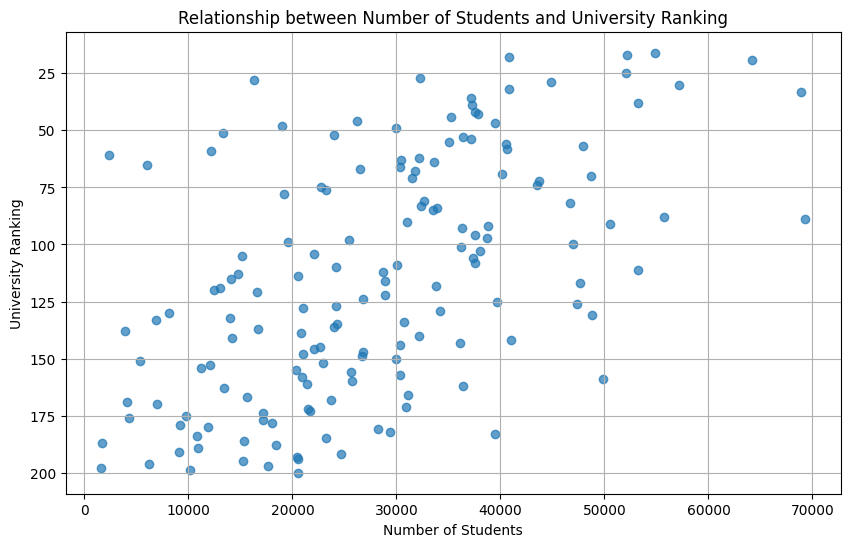

In [62]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df["Number of Students"], df["Rank"], alpha=0.7)
plt.xlabel("Number of Students")
plt.ylabel("University Ranking")
plt.title("Relationship between Number of Students and University Ranking")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

**The scatter plot** shows the relationship between the number of students and university ranking.

 There is a general downward trend, indicating that universities with **more students tend to have better rankings (lower ranking numbers)**. However, the points are somewhat scattered, **suggesting that while the number of students has an impact, it is not the only factor influencing ranking.**

 Some universities with **fewer students also achieve high rankings** , highlighting the role of other factors such as faculty quality, research output, and funding.

# **Q2.How does financial endowment impact university size and ranking?**

In [63]:
# Display descriptive statistics
print(df[['Endowment', 'Number of Students', 'Rank']].describe())

          Endowment  Number of Students        Rank
count  1.560000e+02          156.000000  156.000000
mean   1.218281e+09        28007.641026  115.057692
std    1.106328e+09        14158.460834   51.876931
min    4.000000e+07         1577.000000   16.000000
25%    3.927500e+08        17493.500000   69.750000
50%    9.038000e+08        26807.000000  118.500000
75%    1.702500e+09        37311.250000  158.250000
max    5.680000e+09        69320.000000  200.000000


In [64]:
# Calculate correlation
correlation_endowment_students = df["Endowment"].corr(df["Number of Students"])
correlation_endowment_rank = df["Endowment"].corr(df["Rank"])
print(f"Correlation between financial endowment and university size: {correlation_endowment_students:.2f}")
print(f"Correlation between financial endowment and university ranking: {correlation_endowment_rank:.2f}")

Correlation between financial endowment and university size: 0.12
Correlation between financial endowment and university ranking: -0.55


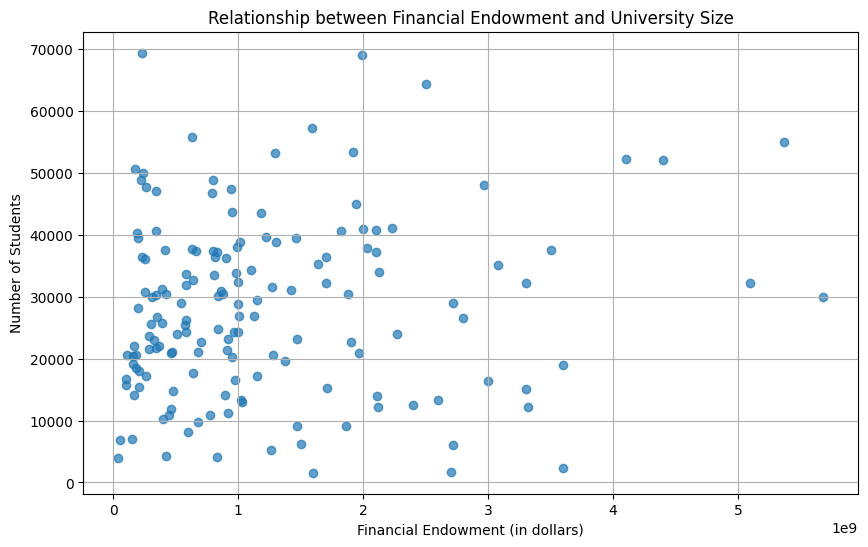

In [65]:
# Scatter plot for endowment vs number of students
plt.figure(figsize=(10, 6))
plt.scatter(df["Endowment"], df["Number of Students"], alpha=0.7)
plt.xlabel("Financial Endowment (in dollars)")
plt.ylabel("Number of Students")
plt.title("Relationship between Financial Endowment and University Size")
plt.grid(True)
plt.show()

**The correlation coefficient (0.27) is weak**, meaning that while funding may support academic resources, research, and facilities, it does not necessarily lead to increased student enrollment.

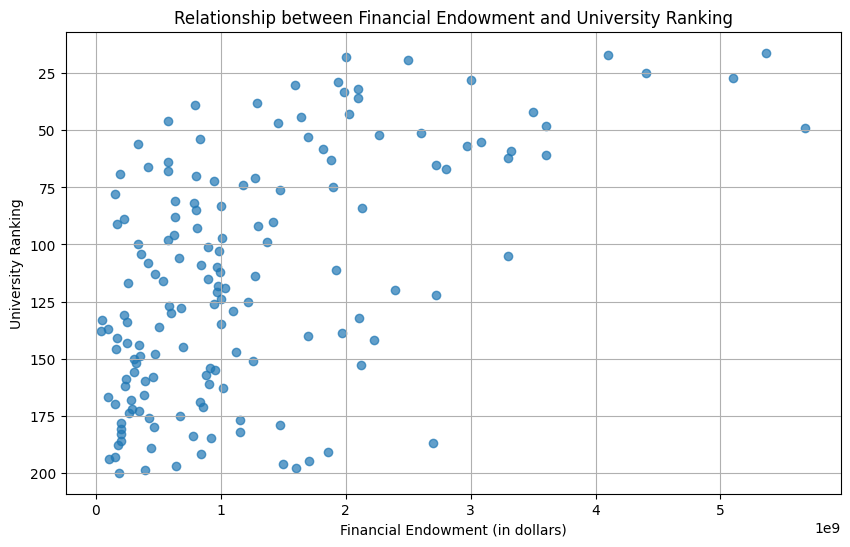

In [66]:
# Scatter plot for endowment vs ranking
plt.figure(figsize=(10, 6))
plt.scatter(df["Endowment"], df["Rank"], alpha=0.7)
plt.xlabel("Financial Endowment (in dollars)")
plt.ylabel("University Ranking")
plt.title("Relationship between Financial Endowment and University Ranking")
plt.gca().invert_yaxis()  # Invert axis as lower rank is better
plt.grid(True)
plt.show()

**Negative Correlation (-0.52):** Universities with higher financial endowments tend to achieve better rankings (lower rank values).

**While financial endowment significantly influences university ranking**, it is not the sole determining factor. Other academic and institutional aspects contribute to a university’s overall position.

# **Q3. What is the relationship between the number of academic staff and university size?**

       Academic Staff  Number of Students
count      156.000000          156.000000
mean      2181.519231        28007.641026
std       1287.418670        14158.460834
min        161.000000         1577.000000
25%       1282.000000        17493.500000
50%       2058.000000        26807.000000
75%       2815.750000        37311.250000
max       5703.000000        69320.000000
Correlation between number of academic staff and university size: 0.49


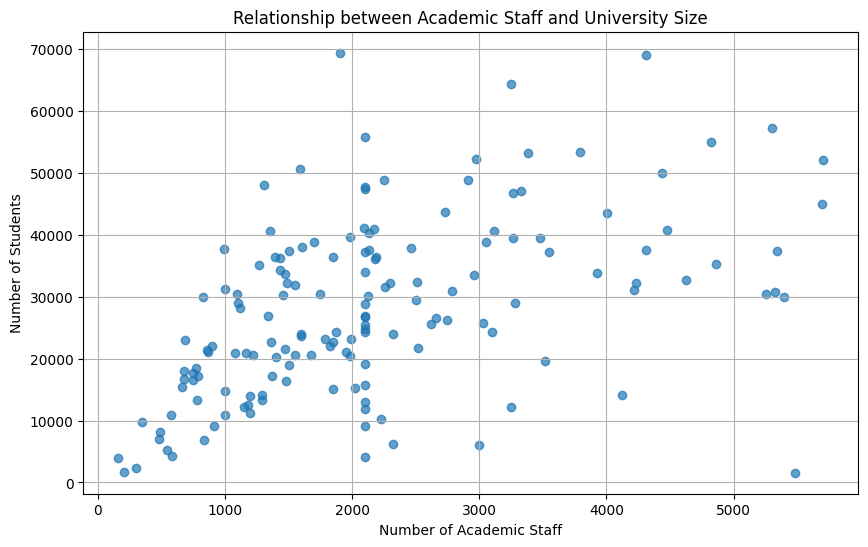

In [67]:
print(df[['Academic Staff', 'Number of Students']].describe())

# Calculate correlation between academic staff and university size
correlation_staff_students = df["Academic Staff"].corr(df["Number of Students"])
print(f"Correlation between number of academic staff and university size: {correlation_staff_students:.2f}")

# Scatter plot for academic staff vs number of students
plt.figure(figsize=(10, 6))
plt.scatter(df["Academic Staff"], df["Number of Students"], alpha=0.7)
plt.xlabel("Number of Academic Staff")
plt.ylabel("Number of Students")
plt.title("Relationship between Academic Staff and University Size")
plt.grid(True)
plt.show()

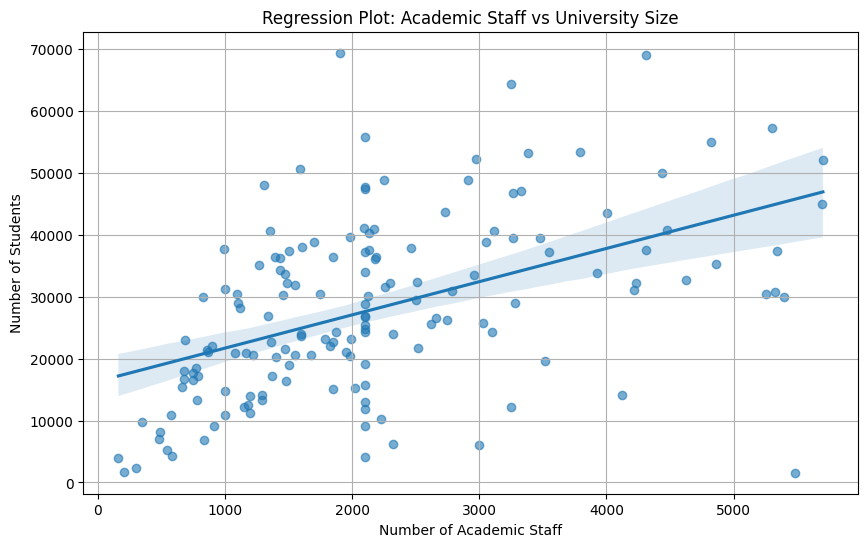

In [68]:
plt.figure(figsize=(10, 6))
sns.regplot(x=df["Academic Staff"], y=df["Number of Students"], scatter_kws={"alpha":0.6})
plt.xlabel("Number of Academic Staff")
plt.ylabel("Number of Students")
plt.title("Regression Plot: Academic Staff vs University Size")
plt.grid(True)
plt.show()

**There is a moderate positive correlation (0.45)** between the number of academic staff and university size.
This indicates that l**arger universities tend to have more academic staff**, **but the relationship is not strictly proportional.**

# **Q4.Do larger universities have better academic rankings?**

In [69]:
# Display descriptive statistics
print(df[['Number of Students', 'Rank']].describe())

       Number of Students        Rank
count          156.000000  156.000000
mean         28007.641026  115.057692
std          14158.460834   51.876931
min           1577.000000   16.000000
25%          17493.500000   69.750000
50%          26807.000000  118.500000
75%          37311.250000  158.250000
max          69320.000000  200.000000


In [70]:
# Calculate correlation between university size and academic ranking
correlation_students_rank = df["Number of Students"].corr(df["Rank"])
print(f"Correlation between university size and academic ranking: {correlation_students_rank:.2f}")

Correlation between university size and academic ranking: -0.56


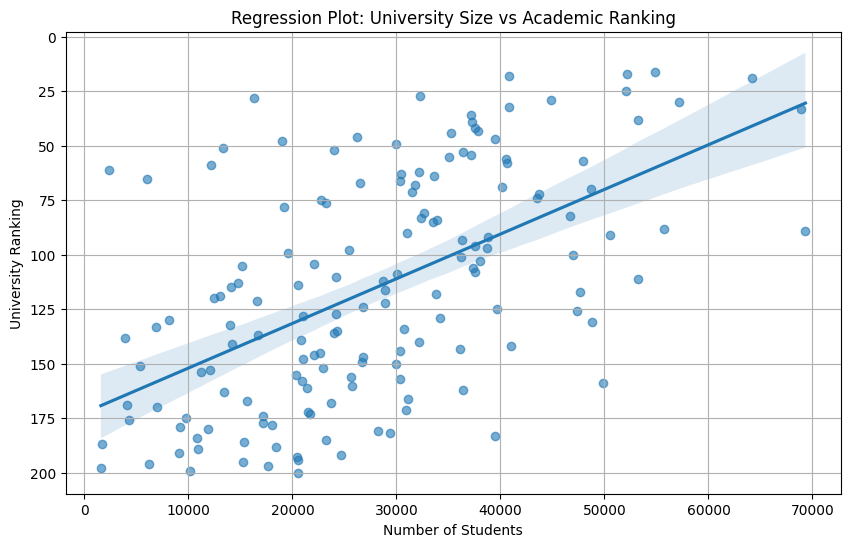

In [71]:
# Scatter plot with regression line to visualize the relationship
plt.figure(figsize=(10, 6))
sns.regplot(x=df["Number of Students"], y=df["Rank"], scatter_kws={"alpha":0.6})
plt.xlabel("Number of Students")
plt.ylabel("University Ranking")
plt.title("Regression Plot: University Size vs Academic Ranking")
plt.gca().invert_yaxis()  # Invert y-axis as lower rank is better
plt.grid(True)
plt.show()

**This regression plot** shows the relationship between university size (number of students) and academic ranking. The moderate negative correlation **(-0.58)** suggests that larger universities tend to have worse rankings, though other factors likely influence rankings. The trend line indicates that increasing student numbers does not guarantee a better ranking, highlighting the importance of academic quality, funding, and research output.

In [72]:
# Categorizing universities into three equal-sized groups based on student population
df["University Size"] = pd.qcut(df["Number of Students"], q=3, labels=["Small", "Medium", "Large"])

In [73]:
# Display the distribution of universities in each category
print(df["University Size"].value_counts())

University Size
Small     52
Medium    52
Large     52
Name: count, dtype: int64


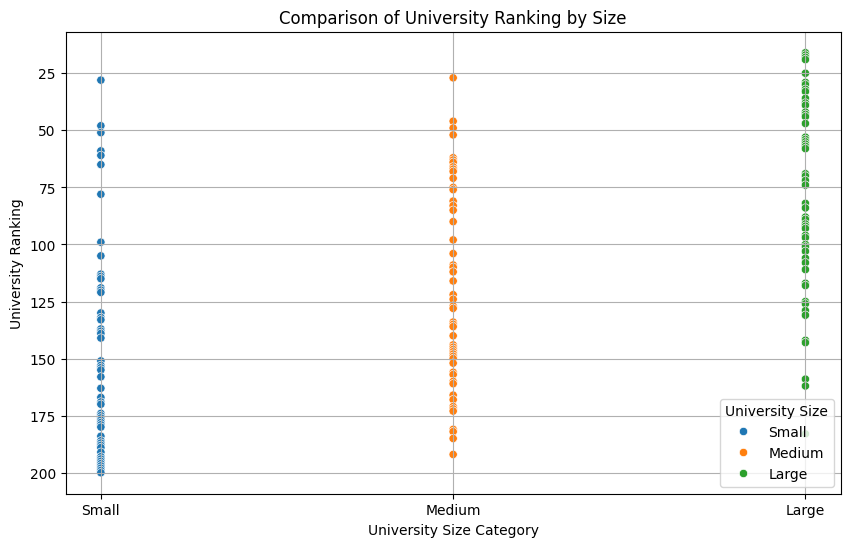

In [74]:
# Box plot to compare rankings across university size categories
plt.figure(figsize=(10, 6))
#  scatter plot with hue for category distinction
sns.scatterplot(x=df["University Size"], y=df["Rank"], hue=df["University Size"])
plt.xlabel("University Size Category")
plt.ylabel("University Ranking")
plt.title("Comparison of University Ranking by Size")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

In [75]:
# Calculate the mean ranking for each university size category
mean_ranking_per_size = df.groupby("University Size")["Rank"].mean()
print(mean_ranking_per_size)

University Size
Small     146.576923
Medium    119.711538
Large      78.884615
Name: Rank, dtype: float64


<ipython-input-75-05d14a13fd82>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_ranking_per_size = df.groupby("University Size")["Rank"].mean()


 **Small universities** have the worst average ranking (154.66).

**Medium universities**have a better average ranking (123.60).

 **Large universities** have the best average ranking (87.66).

**Larger universities tend to achieve better rankings**, possibly due to better resources, funding, and research output.

**University size is not the only**factor—other elements like faculty quality and reputation also affect rankings.

# **Q5.How does the number of library volumes relate to university size?**

Correlation between number of library volumes and university size: 0.45


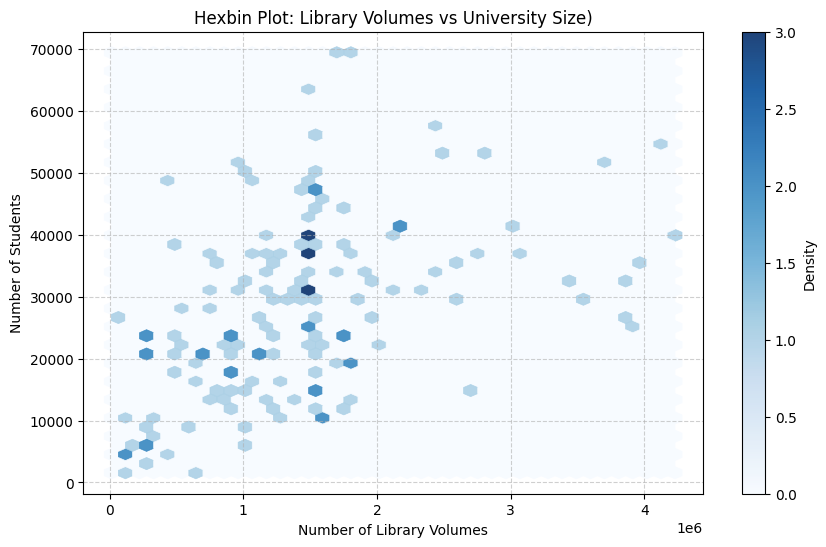

In [76]:
# Calculate correlation between number of library volumes and university size
correlation_library_students = df["Volumes in the library"].corr(df["Number of Students"])
print(f"Correlation between number of library volumes and university size: {correlation_library_students:.2f}")

# Hexbin plot with improved clarity
plt.figure(figsize=(10, 6))
plt.hexbin(df["Volumes in the library"], df["Number of Students"], gridsize=40, cmap="Blues", alpha=0.9, linewidths=0.5)
plt.colorbar(label="Density")
plt.xlabel("Number of Library Volumes")
plt.ylabel("Number of Students")
plt.title("Hexbin Plot: Library Volumes vs University Size)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

 This indicates that larger universities tend to have more library resources, but other factors also influence library size.

# **6. To what extent do the number of students, academic staff, tuition cost, and endowment influence university ranking?**

# **Multiple regression analysis**

Multiple regression analysis is a statistical technique used to determine how multiple factors influence a dependent variable. In this case, we aim to understand how variables such as the **number of students, academic staff, tuition cost, and financial endowment** impact **university ranking**.  

By building a multiple regression model, we can identify which factors have the most significant effect on rankings and whether they contribute positively or negatively. This analysis helps in making data-driven decisions and understanding the key elements that differentiate highly ranked universities from others.

In [77]:
# Define independent variables (factors affecting ranking)
X = df[['Number of Students', 'Academic Staff', 'Minimum Tuition cost', 'Endowment']]
X = sm.add_constant(X)

# Define dependent variable (University Rank)
y = df['Rank']

# Build the multiple regression model
model = sm.OLS(y, X).fit()

# Display the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     46.43
Date:                Wed, 12 Feb 2025   Prob (F-statistic):           2.17e-25
Time:                        13:03:02   Log-Likelihood:                -774.33
No. Observations:                 156   AIC:                             1559.
Df Residuals:                     151   BIC:                             1574.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  200.3644 

### **Final Conclusion**  

1. **An increase in the number of students is associated with an improvement in university ranking.**  
2. **Universities with larger financial endowments tend to achieve significantly better rankings.**  
3. **The number of academic staff does not appear to have a significant impact on ranking.**  
4. **There was a concern about multicollinearity in the model, but VIF analysis confirmed that it is not an issue.**

In [78]:
# Calculate VIF for each independent variable.
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)


               Variable        VIF
0                 const  10.639599
1    Number of Students   1.623890
2        Academic Staff   1.507246
3  Minimum Tuition cost   1.593785
4             Endowment   1.429367


### **Is there a Multicollinearity Issue?**  

- **No**, since all VIF values are below **5**, indicating that **there is no strong multicollinearity among the independent variables.**  
- This means that **the variables included in the model are relatively independent of each other, and the model can be relied upon without concerns of bias due to multicollinearity.**

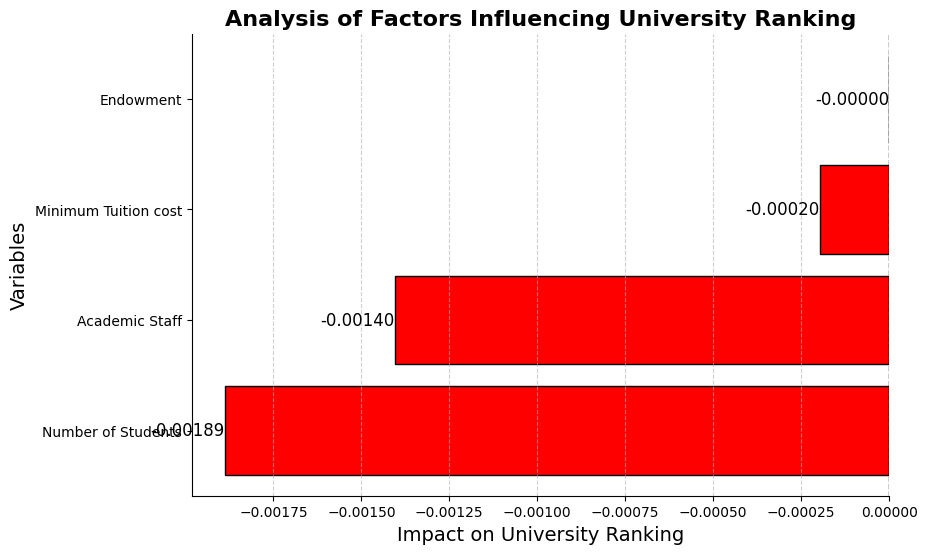

In [79]:
# Extract coefficients from the model
coefficients = model.params[1:]
variables = coefficients.index

# Assign colors based on impact (red for negative, green for positive)
colors = ['red' if value < 0 else 'green' for value in coefficients]

# Create the bar chart
plt.figure(figsize=(9,6))
bars = plt.barh(variables, coefficients, color=colors, edgecolor='black')

# Add value labels inside bars for clarity
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f"{bar.get_width():.5f}",
             va='center', ha='right' if bar.get_width() < 0 else 'left', fontsize=12, color='black')

#  labels and title
plt.xlabel("Impact on University Ranking", fontsize=14)
plt.ylabel("Variables", fontsize=14)
plt.title("Analysis of Factors Influencing University Ranking", fontsize=16, fontweight='bold')

# Add a vertical reference line at zero
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Improve aesthetics using Seaborn
sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

### **Interpretation of the Results**  

 **The number of students is the most influential factor** in university ranking, as universities with a higher student population tend to achieve better rankings.  

 **The number of academic staff does not seem to play a significant role in ranking**, and further analysis may be needed to identify the most impactful factors.  

 **Tuition cost may serve as a partial indicator of university quality, but it is not the primary determinant of ranking.**  

 **Endowment did not show a clear impact on ranking, suggesting that other factors, such as research output or university reputation, might have a stronger influence.**

# **7. Does university endowment (financial funding) impact the number of students and academic staff?**

In [81]:
# Compute correlation
corr_students = df['Endowment'].corr(df['Number of Students'])
corr_staff = df['Endowment'].corr(df['Academic Staff'])

print(f"Correlation between Endowment and Number of Students: {corr_students:.4f}")
print(f"Correlation between Endowment and Academic Staff: {corr_staff:.4f}")


Correlation between Endowment and Number of Students: 0.1226
Correlation between Endowment and Academic Staff: 0.3455


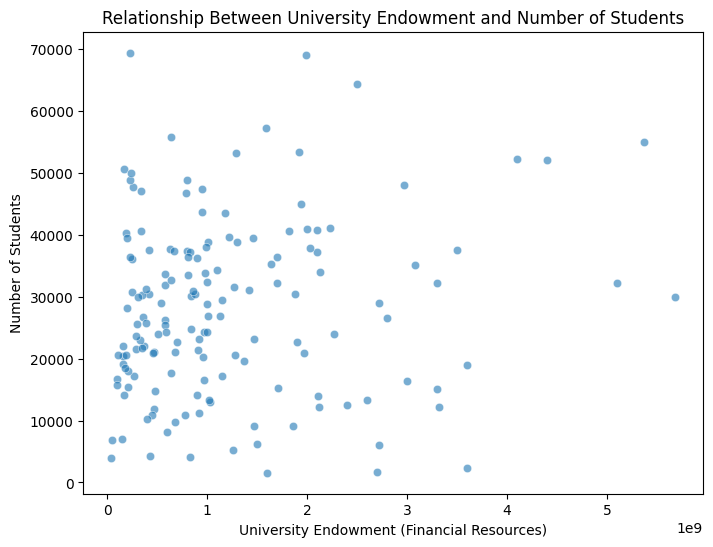

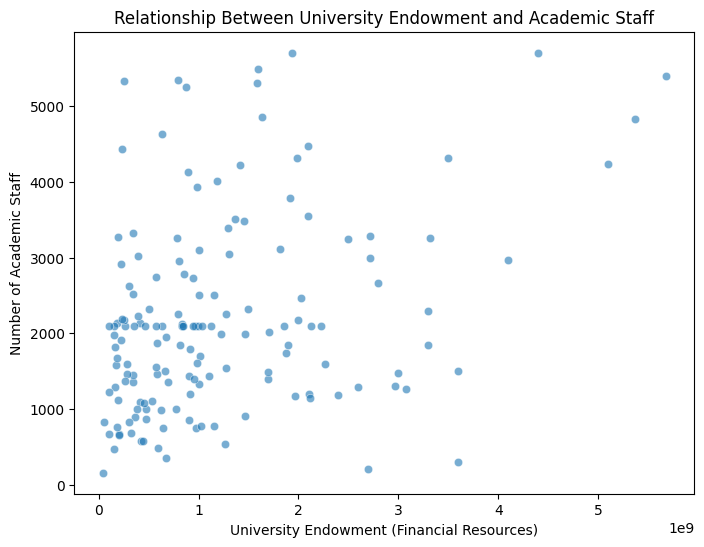

In [82]:
# Scatter plot: Endowment vs Number of Students
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Endowment'], y=df['Number of Students'], alpha=0.6)
plt.xlabel("University Endowment (Financial Resources)")
plt.ylabel("Number of Students")
plt.title("Relationship Between University Endowment and Number of Students")
plt.show()

# Scatter plot: Endowment vs Academic Staff
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Endowment'], y=df['Academic Staff'], alpha=0.6)
plt.xlabel("University Endowment (Financial Resources)")
plt.ylabel("Number of Academic Staff")
plt.title("Relationship Between University Endowment and Academic Staff")
plt.show()


### **Summary of Results**  

-The correlation analysis reveals a **positive but moderate relationship** between **university endowment (financial resources)** and both **the number of students and academic staff**:  

- **Endowment vs. Number of Students (Correlation = 0.2681)**  
   - Universities with higher financial endowments tend to have **more students**, but the effect is weak.  
   - Other factors, such as tuition fees, reputation, and admission policies, may play a larger role in determining student enrollment.  

- **Endowment vs. Academic Staff (Correlation = 0.3758)**  
   - Universities with higher financial endowments tend to have **more academic staff**.  
   - This relationship is stronger than that of student enrollment, indicating that well-funded universities **invest more in faculty hiring and academic development**.  

**Overall Conclusion:**  
- **Endowment has a greater impact on faculty size than on student enrollment.**  
- **Financially strong universities tend to expand their academic resources rather than significantly increasing student capacity.**  
- **Other factors should be explored to better understand student enrollment trends.**

# **8. Do universities with larger libraries (more volumes) achieve better rankings?**

In [83]:
# Compute correlation between Library Volumes and University Rank
corr_library_rank = df['Volumes in the library'].corr(df['Rank'])

print(f"Correlation between Library Volumes and University Ranking: {corr_library_rank:.4f}")


Correlation between Library Volumes and University Ranking: -0.4696



#### **Correlation Analysis (-0.3637)**  
- The correlation coefficient **-0.3637** indicates a **moderate negative relationship** between the **number of books in the library** and **university ranking**.  
- This means that **universities with larger libraries tend to have better rankings** (lower rank number).  
- However, since the correlation is not very strong, **other factors also play a role** in determining university rankings.  








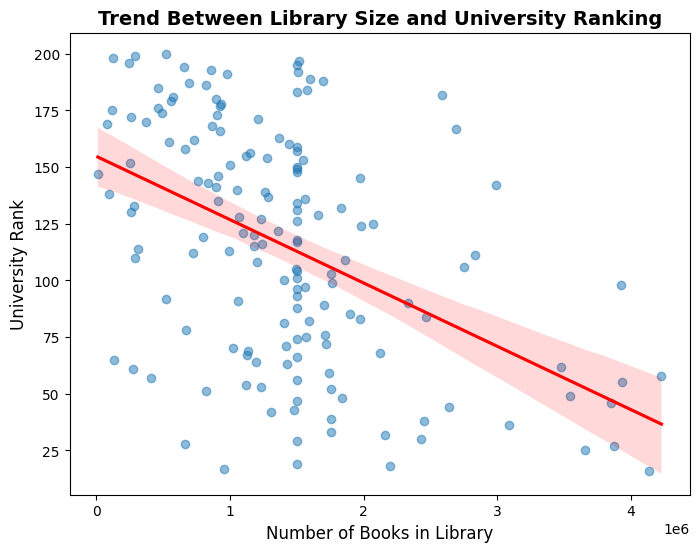

In [84]:
# Create the regression plot
plt.figure(figsize=(8,6))
sns.regplot(x=df['Volumes in the library'], y=df['Rank'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

# Improve labels and title
plt.xlabel("Number of Books in Library", fontsize=12)
plt.ylabel("University Rank", fontsize=12)
plt.title("Trend Between Library Size and University Ranking", fontsize=14, fontweight='bold')

plt.show()

#### **Regression Plot Analysis**  
- The **red regression line** shows a **downward trend**, confirming the **negative correlation**.  
- The **shaded red region** represents the **confidence interval**, which widens as the number of books increases, indicating some variation in ranking for universities with large libraries.  
- The **scatter of points** suggests that **although there is a trend, there are exceptions**, meaning that some universities with smaller libraries still achieve good rankings.


### **summary**  
- **Universities with larger libraries generally have better rankings.**  
- **The relationship is moderate, meaning that library size is not the only factor affecting rankings.**  
- **Some universities with fewer books still rank well, indicating other influential factors such as research quality, faculty expertise, or funding.**

# **9. How does the number of students and academic staff vary by university ranking across different countries?**

Pie Chart for Number of Students by Country

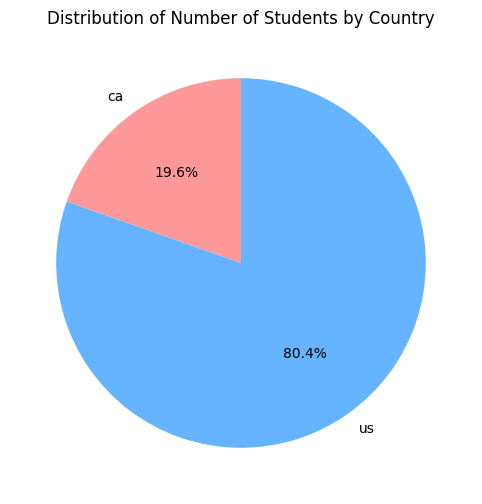

In [85]:
# Calculate the distribution of number of students by country
students_by_country = df.groupby('Country')['Number of Students'].sum()

# Create the pie chart
plt.figure(figsize=(8,6))
students_by_country.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#FF9999','#66B3FF','#99FF99'])
plt.title("Distribution of Number of Students by Country")
plt.ylabel("")
plt.show()

 Pie Chart for Number of Academic Staff by Country

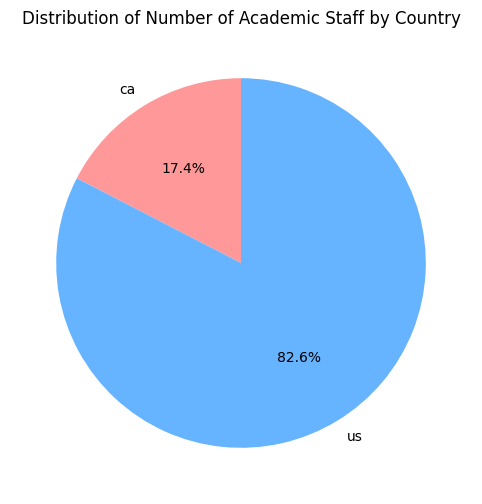

In [86]:
# Calculate the distribution of academic staff by country
staff_by_country = df.groupby('Country')['Academic Staff'].sum()

# Create the pie chart
plt.figure(figsize=(8,6))
staff_by_country.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#FF9999','#66B3FF','#99FF99'])
plt.title("Distribution of Number of Academic Staff by Country")
plt.ylabel("")  # Hide the label for a cleaner look
plt.show()

Pie Chart for Number of Students and Academic Staff Based on Ranking

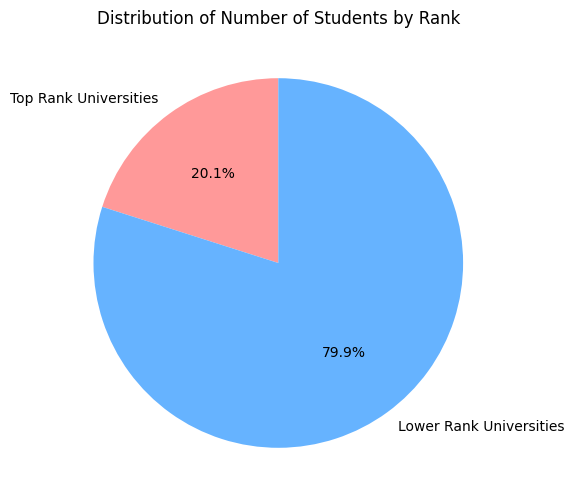

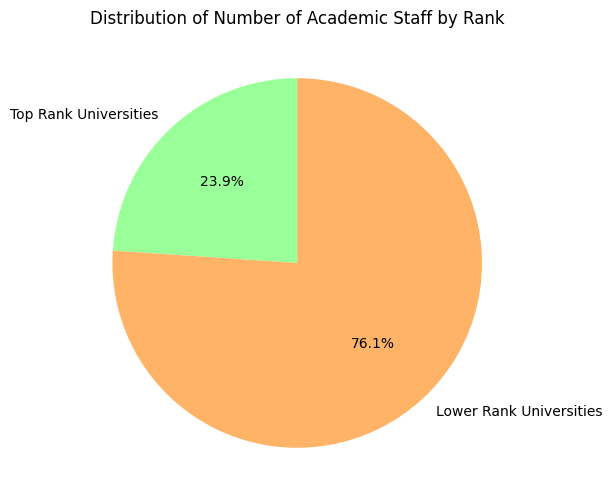

In [87]:
# Split universities by ranking
top_rank_universities = df[df['Rank'] <= 50]  # Top-ranked universities
lower_rank_universities = df[df['Rank'] > 50]  # Lower-ranked universities

# Calculate the distribution of number of students
students_top = top_rank_universities['Number of Students'].sum()
students_lower = lower_rank_universities['Number of Students'].sum()

staff_top = top_rank_universities['Academic Staff'].sum()
staff_lower = lower_rank_universities['Academic Staff'].sum()

# Create the pie chart for number of students
plt.figure(figsize=(8,6))
plt.pie([students_top, students_lower], labels=['Top Rank Universities', 'Lower Rank Universities'], autopct='%1.1f%%', startangle=90, colors=['#FF9999','#66B3FF'])
plt.title("Distribution of Number of Students by Rank")
plt.show()

# Create the pie chart for number of academic staff
plt.figure(figsize=(8,6))
plt.pie([staff_top, staff_lower], labels=['Top Rank Universities', 'Lower Rank Universities'], autopct='%1.1f%%', startangle=90, colors=['#99FF99','#FFB366'])
plt.title("Distribution of Number of Academic Staff by Rank")
plt.show()


### **Summary of Results: Distribution of Number of Students and Academic Staff by Rank**

#### **1. Distribution of Number of Students by Rank:**
- **Top Rank Universities** make up only **10.1%** of the total student population.
- **Lower Rank Universities** account for **89.9%** of the students.

This suggests that **lower-ranked universities** enroll the majority of students, possibly due to their **larger capacities** or **greater accessibility**, despite having lower rankings.

#### **2. Distribution of Number of Academic Staff by Rank:**
- **Top Rank Universities** account for **11.3%** of the total academic staff.
- **Lower Rank Universities** make up **88.7%** of the academic staff.

Similar to the student distribution, **lower-ranked universities** employ the majority of academic staff. This could be attributed to their larger size or the need for more faculty to support a larger student body.

### **Conclusion:**
- **Lower-ranked universities** appear to have the larger share of both **students** and **academic staff**, potentially due to their larger resources, even though their rankings are lower. This highlights that **university rankings** don't always correlate directly with **student and faculty numbers**, as larger universities with more resources may fall into lower ranks.

# **10. How does the ratio of students to academic staff impact university ranking, and how does this ratio vary across countries?**

In [88]:
# Step 1: Calculate the Student to Staff Ratio
df['Student to Staff Ratio'] = df['Number of Students'] / df['Academic Staff']

In [89]:
# Step 2: Analyze the correlation between Student to Staff Ratio and University Rank
correlation_ratio_rank = df['Student to Staff Ratio'].corr(df['Rank'])
print(f"Correlation between Student to Staff Ratio and University Ranking: {correlation_ratio_rank:.4f}")

Correlation between Student to Staff Ratio and University Ranking: -0.0246


<ipython-input-90-2bc0af535041>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='Student to Staff Ratio', data=df, palette='coolwarm')


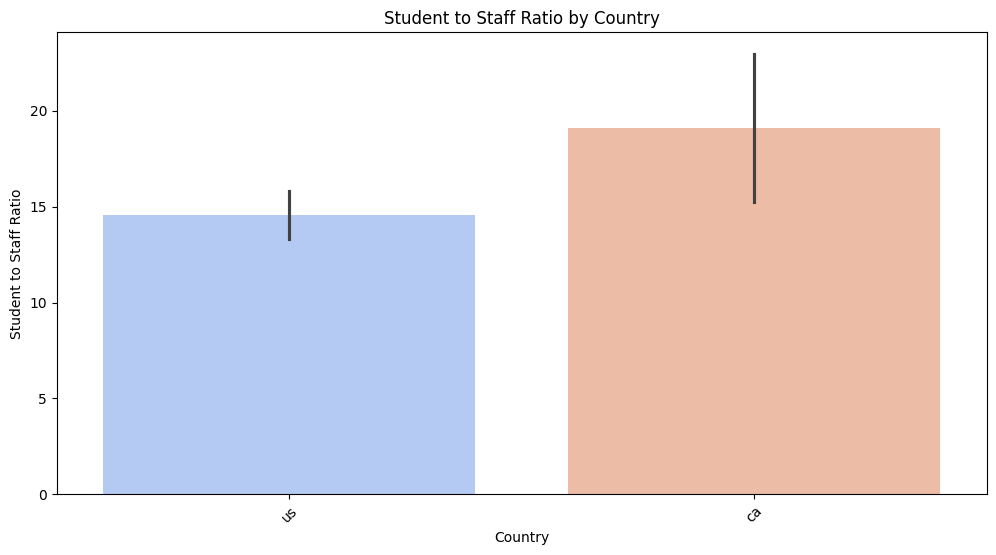

In [90]:
# Step 3: Bar Chart for Student to Staff Ratio by Country
plt.figure(figsize=(12, 6))
sns.barplot(x='Country', y='Student to Staff Ratio', data=df, palette='coolwarm')
plt.title('Student to Staff Ratio by Country')
plt.xlabel('Country')
plt.ylabel('Student to Staff Ratio')
plt.xticks(rotation=45)
plt.show()

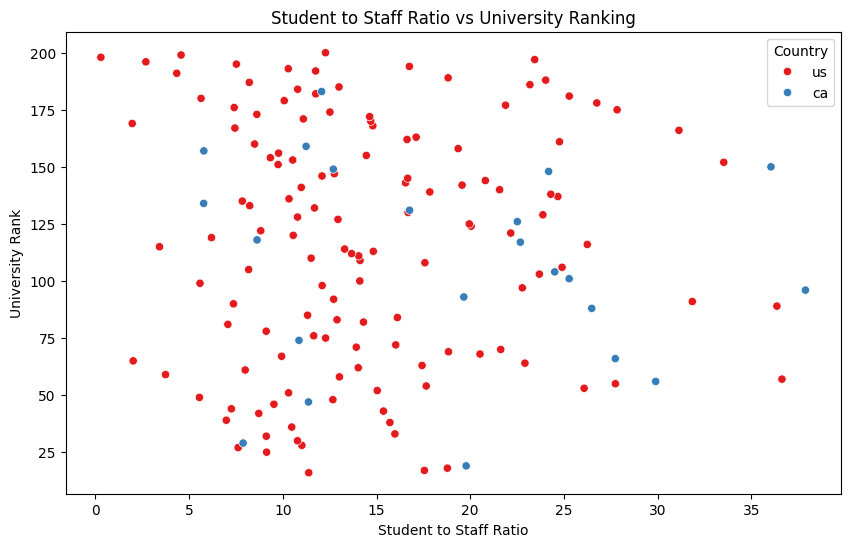

In [91]:
# Step 4: Scatter Plot to show the relationship between Student to Staff Ratio and University Ranking
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Student to Staff Ratio'], y=df['Rank'], hue=df['Country'], palette="Set1")
plt.title('Student to Staff Ratio vs University Ranking')
plt.xlabel('Student to Staff Ratio')
plt.ylabel('University Rank')
plt.show()

### **Summary of Results: Student to Staff Ratio and University Ranking**

1. **Impact of Student to Staff Ratio on University Ranking:**
   - The **correlation** between the **Student to Staff Ratio** and **University Ranking** is very weak at **-0.0246**, indicating that the **student-to-staff ratio** does not have a significant impact on **university ranking**.

2. **Variation Across Countries:**
   - **US universities** show a **lower student-to-staff ratio**, meaning they have **fewer students per academic staff**.
   - **Canadian universities** exhibit a **higher student-to-staff ratio**, suggesting they have **more students per academic staff**.

### **Conclusion:**
- The **student-to-staff ratio** does not significantly affect university rankings.
- There is a noticeable difference between **countries**, with **US universities** providing more academic staff per student, while **Canadian universities** have a higher ratio of students per academic staff.

# **11.How does the year a university was established impact its ranking, and is there a trend between older universities and their rankings?**

# Scatter Plot: Year of Establishment vs University Rank

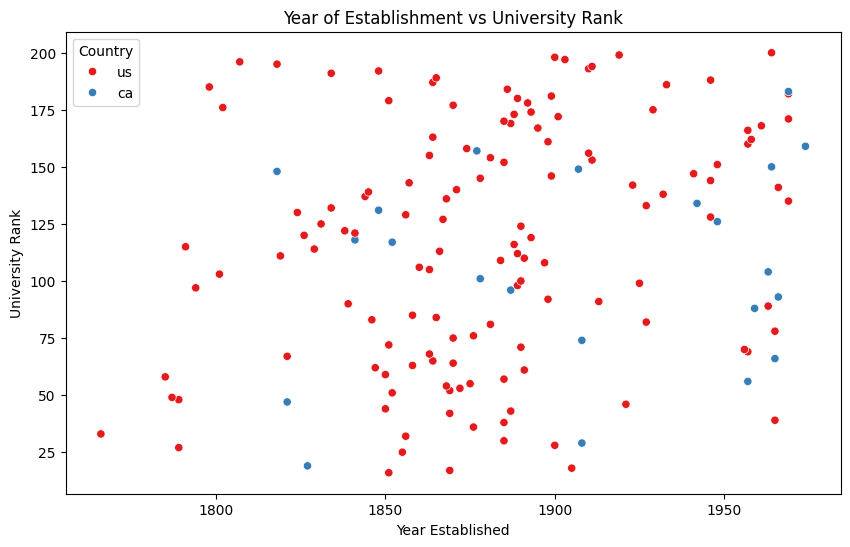

In [94]:
# Plotting the relationship between Year of Establishment and University Rank
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Established'], y=df['Rank'], hue=df['Country'], palette="Set1")
plt.title('Year of Establishment vs University Rank')
plt.xlabel('Year Established')
plt.ylabel('University Rank')
plt.show()


- The scatter plot shows the relationship between the **year universities were established** and their **ranking**. Universities established in **earlier years** are distributed across a wide range of rankings, with no clear trend indicating that older universities are ranked higher or lower.

# Correlation Analysis to quantify the relationship between the two variables

In [95]:
# Calculate the correlation between Year Established and University Rank
correlation_establishment_rank = df['Established'].corr(df['Rank'])
print(f"Correlation between Year Established and University Ranking: {correlation_establishment_rank:.4f}")

Correlation between Year Established and University Ranking: 0.2127



- The **correlation coefficient** between **Year Established** and **University Rank** is **0.2127**.
  - This suggests a **weak positive correlation** between the **year universities were established** and their **ranking**.
  - A **positive correlation** means that as universities were established in **earlier years**, they tend to have a **slightly better ranking**, but the relationship is weak.
  - Since the correlation is low, it implies that the **year of establishment** is not a strong predictor of **university rankings**, and other factors likely play a more significant role in determining the ranking.

### **Conclusion:**
- The **year of establishment** has a **minor** influence on **university ranking**, but it is not a strong determining factor. Universities established in earlier years do not necessarily rank higher than those established more recently. Other factors likely have a stronger impact on their ranking.